# Неделя 4. Общий анализ данных — практическая часть

## 0. Окружение

In [1]:
import platform
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 80)

print(f"Python     {platform.python_version()}")
print(f"NumPy      {np.__version__}")
print(f"pandas     {pd.__version__}")

SRC_CSV = Path("dataset.csv")            # сводная таблица недели 3 (клиника + радиомика GTVp), не изменяется
OUT_CSV = Path("analytic_table.csv")
MISSING_SHARE_MAX = 0.30                 # порог исключения переменной из-за пропусков
CORR_THRESHOLD = 0.90                    # порог |rho Спирмена| для сокращения избыточности

Python     3.11.15
NumPy      2.4.6
pandas     3.0.6


## 1. Исходная таблица

In [2]:
raw = pd.read_csv(SRC_CSV, dtype=str, keep_default_na=False)   # всё как текст, без автоматического распознавания пропусков
src = pd.read_csv(SRC_CSV)                                      # та же таблица с автоматическими типами

ID, TARGET_SRC = "Patient_ID", "Local_tumor_recurrence"
radiomic_cols = [c for c in src.columns if c.startswith("GTVp_")]
clinical_cols = [c for c in src.columns if c not in radiomic_cols]

print(f"Пациентов (строк): {len(src)}; уникальных {ID}: {src[ID].nunique()}")
print(f"Столбцов: {src.shape[1]} = {len(clinical_cols)} клинических и служебных + {len(radiomic_cols)} радиомических")
print()
print(src[clinical_cols].dtypes.to_string())

Пациентов (строк): 298; уникальных Patient_ID: 298
Столбцов: 127 = 20 клинических и служебных + 107 радиомических

Patient_ID                                     int64
Fold                                             str
Local_tumor_recurrence                       float64
Gender                                           str
Age_at_diagnosis                               int64
Race                                             str
Tumor_side                                       str
Tumor_subsite                                    str
T_category                                     int64
N_category                                       str
AJCC_Stage                                       str
Pathological_grade                               str
Smoking_status_at_diagnosis                      str
Smoking_Pack-Years                           float64
Radiation_treatment_course_duration            int64
Total_prescribed_Radiation_treatment_dose      int64
#_Radiation_treatment_fractions      

## 2. Проверка значений
### 2.1. Наименьшее и наибольшее значения количественных переменных

In [3]:
categorical = ["Fold", "Gender", "Race", "Tumor_side", "Tumor_subsite", "T_category", "N_category", "AJCC_Stage",
               "Pathological_grade", "Smoking_status_at_diagnosis", "Induction_Chemotherapy",
               "Concurrent_chemotherapy", TARGET_SRC, "KM_Overall_survival_censor"]
quantitative = [c for c in src.columns if c not in categorical + [ID]]

rng = pd.DataFrame({"min": src[quantitative].min(), "max": src[quantitative].max(),
                    "n_missing": src[quantitative].isna().sum()})
print(f"Количественных переменных: {len(quantitative)} "
      f"({len(quantitative) - len(radiomic_cols)} клинических + {len(radiomic_cols)} радиомических)")
with pd.option_context("display.max_rows", 200, "display.float_format", "{:.4g}".format):
    display(rng)

Количественных переменных: 112 (5 клинических + 107 радиомических)


,min,max,n_missing
Age_at_diagnosis,30,89,0
Smoking_Pack-Years,0,203,14
Radiation_treatment_course_duration,32,56,0
Total_prescribed_Radiation_treatment_dose,60,72,0
#_Radiation_treatment_fractions,30,40,0
GTVp_shape_Elongation,0.2656,0.9844,0
GTVp_shape_Flatness,0.1314,0.8013,0
GTVp_shape_LeastAxisLength,3.11,51.72,0
GTVp_shape_MajorAxisLength,12.05,113.2,0
GTVp_shape_Maximum2DDiameterColumn,13.15,118.1,0


### 2.2. Все встречающиеся значения категориальных переменных (исходная запись)

In [4]:
for c in categorical:
    vc = raw[c].value_counts().sort_index()
    print(f"{c}: " + ", ".join(f"{v!r}: {n}" for v, n in vc.items()))
print()
tokens = {v for c in raw.columns for v in raw[c].unique() if v.strip().upper() in {"", "NA", "N/A", "NAN", "NONE", "X", "UNKNOWN", "?", "-"}}
print("Обозначения пропусков и служебные коды, встречающиеся в файле:", sorted(tokens))
print("Пустых ячеек по столбцам:", {c: int((raw[c] == "").sum()) for c in raw.columns if (raw[c] == "").any()})
print("Ячеек 'X' по столбцам:", {c: int((raw[c] == "X").sum()) for c in raw.columns if (raw[c] == "X").any()})

Fold: 'Test': 158, 'Training': 140
Gender: 'Female': 49, 'Male': 249
Race: '': 1, 'American_Indian/Alaska_Native': 1, 'Asian': 3, 'Black': 13, 'Hispanic': 11, 'White': 269
Tumor_side: 'Bilateral': 1, 'L': 152, 'R': 145
Tumor_subsite: 'BOT': 149, 'GPS': 12, 'Other': 15, 'Pharyngeal_wall': 3, 'Soft_palate': 5, 'Tonsil': 114
T_category: '1': 71, '2': 121, '3': 59, '4': 47
N_category: '0': 27, '1': 38, '2a': 26, '2b': 130, '2c': 68, '3': 8, 'X': 1
AJCC_Stage: 'I': 3, 'II': 11, 'III': 46, 'IV': 237, 'X': 1
Pathological_grade: '': 43, 'I': 4, 'I-II': 1, 'II': 103, 'II-III': 12, 'III': 132, 'IV': 3
Smoking_status_at_diagnosis: 'Current': 82, 'Former': 111, 'Never': 105
Induction_Chemotherapy: 'N': 197, 'Y': 101
Concurrent_chemotherapy: 'N': 70, 'Y': 228
Local_tumor_recurrence: '': 158, '0.0': 128, '1.0': 12
KM_Overall_survival_censor: '0': 60, '1': 238

Обозначения пропусков и служебные коды, встречающиеся в файле: ['', 'X']
Пустых ячеек по столбцам: {'Local_tumor_recurrence': 158, 'Race': 1,

### 2.3. Согласованность значений между переменными

In [5]:
def ajcc7_stage(t, n):
    """Стадия AJCC 7 для рака ротоглотки по T и N (M0 — все пациенты получали радикальную ЛТ)."""
    if n in (None, "X") or pd.isna(n):
        return np.nan
    if t == 4 or n in ("2a", "2b", "2c", "3"):
        return "IV"
    if t == 3 or n == "1":
        return "III"
    return {1: "I", 2: "II"}[t]

expected = [ajcc7_stage(t, n) for t, n in zip(src.T_category, src.N_category)]
stage_bad = src[(pd.Series(expected) != src.AJCC_Stage) & pd.notna(expected)]
print(f"AJCC_Stage не соответствует T и N: {len(stage_bad)}")
print(stage_bad[[ID, "Fold", "T_category", "N_category", "AJCC_Stage"]].assign(expected=[expected[i] for i in stage_bad.index]).to_string(index=False))
print()

print(pd.crosstab(src.Smoking_status_at_diagnosis,
                  pd.cut(src["Smoking_Pack-Years"], [-1, 0, 10, 1000], labels=["0", "(0;10]", ">10"]).astype(str)
                  .where(src["Smoking_Pack-Years"].notna(), "пропуск")))
smoke_bad = src[(src.Smoking_status_at_diagnosis != "Never") & (src["Smoking_Pack-Years"] == 0)]
print(f"\nКурящие или бывшие курильщики с 0 пачко-лет: {len(smoke_bad)}")
print(smoke_bad[[ID, "Fold", "Smoking_status_at_diagnosis", "Smoking_Pack-Years"]].to_string(index=False))
print()

dose, frac = src.Total_prescribed_Radiation_treatment_dose, src["#_Radiation_treatment_fractions"]
print("Доза на фракцию, Гр:", (dose / frac).round(2).value_counts().sort_index().to_dict())
ratio = src.Radiation_treatment_course_duration / frac
print(f"Длительность курса / число фракций: {ratio.min():.2f}–{ratio.max():.2f} сут на фракцию")
print()
hu_low, hu_high = src.GTVp_firstorder_Minimum < -1024, src.GTVp_firstorder_Maximum > 3071
print(f"GTVp_firstorder_Minimum < -1024 HU: {hu_low.sum()} пациентов (из них Training: {(hu_low & (src.Fold == 'Training')).sum()})")
print(f"GTVp_firstorder_Maximum > 3071 HU: {hu_high.sum()} пациентов (из них Training: {(hu_high & (src.Fold == 'Training')).sum()})")
print(f"Пациенты с погрешностями маски по итогам недели 3 (219, 257, 289): "
      f"{src.loc[src[ID].isin([219, 257, 289]), 'Fold'].tolist()}")

AJCC_Stage не соответствует T и N: 1
 Patient_ID     Fold  T_category N_category AJCC_Stage expected
         15 Training           4          1        III       IV

Smoking_Pack-Years           (0;10]    0  >10  пропуск
Smoking_status_at_diagnosis                           
Current                          13    4   58        7
Former                           36    3   65        7
Never                             0  105    0        0

Курящие или бывшие курильщики с 0 пачко-лет: 7
 Patient_ID     Fold Smoking_status_at_diagnosis  Smoking_Pack-Years
         83 Training                     Current                 0.0
        158 Training                      Former                 0.0
        180     Test                     Current                 0.0
        237     Test                      Former                 0.0
        241     Test                      Former                 0.0
        256     Test                     Current                 0.0
        259     Test        

### 2.4. Исправление значений (исходный файл не изменяется)

In [6]:
df = src.copy()
log = []

def fix(mask, col, new, reason):
    n = int(mask.sum())
    for pid, old in zip(df.loc[mask, ID], df.loc[mask, col]):
        log.append({ID: pid, "variable": col, "old": old, "new": new, "reason": reason})
    df.loc[mask, col] = new
    return n

# 1) служебный код 'X' («не может быть оценена») -> единая отметка пропуска
for c in ["N_category", "AJCC_Stage"]:
    fix(df[c] == "X", c, np.nan, "служебный код X -> пропуск")
# 2) стадия однозначно восстанавливается по T и N (AJCC 7)
exp = pd.Series([ajcc7_stage(t, n) for t, n in zip(df.T_category, df.N_category)], index=df.index)
bad = exp.notna() & df.AJCC_Stage.notna() & (exp != df.AJCC_Stage)
for idx in df.index[bad]:
    fix(df.index == idx, "AJCC_Stage", exp[idx], "стадия противоречит T и N, пересчитана по AJCC 7")
# 3) 0 пачко-лет у курящих/бывших курильщиков — противоречие, верное значение не восстановимо -> пропуск
fix((df.Smoking_status_at_diagnosis != "Never") & (df["Smoking_Pack-Years"] == 0), "Smoking_Pack-Years", np.nan,
    "0 пачко-лет при статусе Current/Former -> пропуск")

log = pd.DataFrame(log)
print(log.to_string(index=False))
print()
changed = log.groupby("variable").size().rename("изменено значений")
print(changed.to_string())
print(f"Всего изменено значений: {len(log)}")
print()
blank = {c: int((raw[c] == "").sum()) for c in raw.columns if (raw[c] == "").any()}
print("Пустые ячейки исходного файла, прочитанные как пропуск (NaN):", blank)
assert pd.read_csv(SRC_CSV).equals(src), "исходный файл изменился"
print("Исходный файл не изменён:", True)

 Patient_ID           variable  old new                                            reason
        258         N_category    X NaN                        служебный код X -> пропуск
        258         AJCC_Stage    X NaN                        служебный код X -> пропуск
         15         AJCC_Stage  III  IV  стадия противоречит T и N, пересчитана по AJCC 7
         83 Smoking_Pack-Years  0.0 NaN 0 пачко-лет при статусе Current/Former -> пропуск
        158 Smoking_Pack-Years  0.0 NaN 0 пачко-лет при статусе Current/Former -> пропуск
        180 Smoking_Pack-Years  0.0 NaN 0 пачко-лет при статусе Current/Former -> пропуск
        237 Smoking_Pack-Years  0.0 NaN 0 пачко-лет при статусе Current/Former -> пропуск
        241 Smoking_Pack-Years  0.0 NaN 0 пачко-лет при статусе Current/Former -> пропуск
        256 Smoking_Pack-Years  0.0 NaN 0 пачко-лет при статусе Current/Former -> пропуск
        259 Smoking_Pack-Years  0.0 NaN 0 пачко-лет при статусе Current/Former -> пропуск

variable


### 2.5. Даты

In [7]:
date_like = [c for c in raw.columns if any(k in c.lower() for k in ("date", "time", "day", "дата"))]
print("Столбцы с датами или временем в названии:", date_like)
print("Распознаются как даты:", [c for c in raw.columns
                                 if pd.to_datetime(raw[c].replace("", np.nan), errors="coerce", format="mixed").notna().mean() > 0.9
                                 and not raw[c].str.fullmatch(r"-?[\d.eE+-]*").all()])

Столбцы с датами или временем в названии: []


Распознаются как даты: []


### 2.6. Вычисляемая переменная

In [8]:
df["Dose_per_fraction"] = (df.Total_prescribed_Radiation_treatment_dose / df["#_Radiation_treatment_fractions"]).round(3)
print(df.Dose_per_fraction.describe()[["min", "50%", "max"]].to_string())

min    1.800
50%    2.121
max    2.400


### 2.7. Пропуски

In [9]:
miss = pd.DataFrame({"n_missing": df.isna().sum(), "share_%": (df.isna().mean() * 100).round(1)})
miss = miss[miss.n_missing > 0].sort_values("n_missing", ascending=False)
print(f"Переменных с пропусками: {len(miss)} из {df.shape[1]}")
print(miss.to_string())
print()
print(f"Пропусков в радиомических признаках: {int(df[radiomic_cols].isna().sum().sum())}")

Переменных с пропусками: 6 из 128
                        n_missing  share_%
Local_tumor_recurrence        158     53.0
Pathological_grade             43     14.4
Smoking_Pack-Years             21      7.0
Race                            1      0.3
AJCC_Stage                      1      0.3
N_category                      1      0.3

Пропусков в радиомических признаках: 0


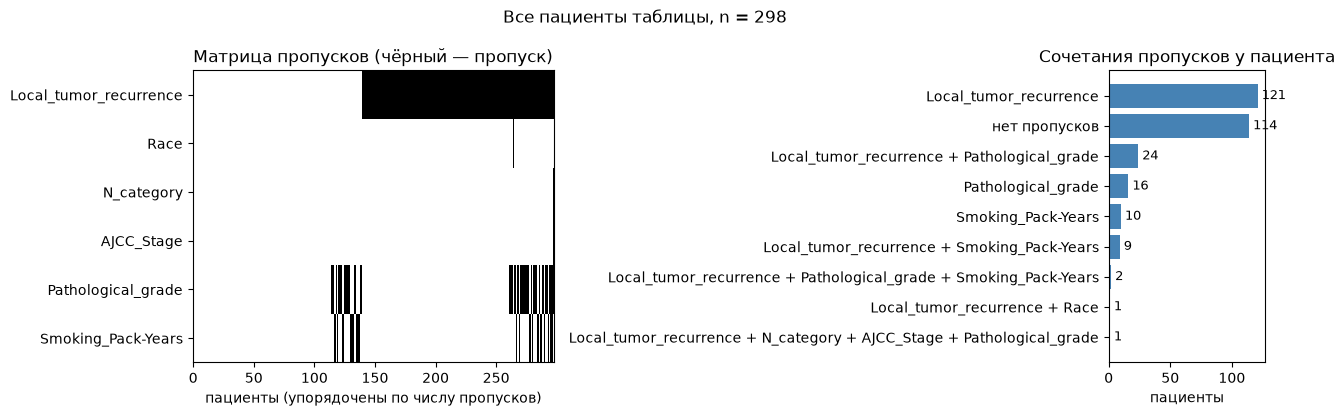

In [10]:
def plot_missing(frame, title):
    cols = frame.columns[frame.isna().any()]
    m = frame[cols].isna()
    order = m.sum(axis=1).sort_values(kind="stable").index
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [3, 1.3]})
    ax1.imshow(m.loc[order].T.to_numpy(), aspect="auto", cmap="Greys", interpolation="nearest")
    ax1.set_yticks(range(len(cols)), cols)
    ax1.set_xlabel("пациенты (упорядочены по числу пропусков)")
    ax1.set_title("Матрица пропусков (чёрный — пропуск)")
    combos = m.apply(lambda r: " + ".join(c for c, v in r.items() if v) or "нет пропусков", axis=1).value_counts()
    ax2.barh(combos.index[::-1], combos.values[::-1], color="steelblue")
    for y, v in enumerate(combos.values[::-1]):
        ax2.text(v, y, f" {v}", va="center", fontsize=9)
    ax2.set_title("Сочетания пропусков у пациента")
    ax2.set_xlabel("пациенты")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

plot_missing(df[clinical_cols + ["Dose_per_fraction"]], f"Все пациенты таблицы, n = {len(df)}")

## 3. Целевая переменная

In [11]:
print(pd.crosstab(df.Fold, df[TARGET_SRC].map({0: "0", 1: "1"}).fillna("не определён"), margins=True, margins_name="всего"))
df["Target_local_recurrence"] = df[TARGET_SRC].astype("Int64")   # 1 — локальный рецидив, 0 — нет, <NA> — скрыт организаторами
vc = df.Target_local_recurrence.value_counts(dropna=False)
print()
print(f"Исход 1: {vc.get(1, 0)}; исход 0: {vc.get(0, 0)}; не определён: {df.Target_local_recurrence.isna().sum()}")

cohort = df[df.Target_local_recurrence.notna()].copy()
print(f"Исключено пациентов с неопределённым исходом: {len(df) - len(cohort)}")
print(f"Осталось пациентов: {len(cohort)}; доля исхода 1: {cohort.Target_local_recurrence.mean():.1%}")
print("Переменных со временем наблюдения или датой события в таблице:", [c for c in df.columns if "time" in c.lower() or "date" in c.lower()])

Local_tumor_recurrence    0   1  не определён  всего
Fold                                                
Test                      0   0           158    158
Training                128  12             0    140
всего                   128  12           158    298

Исход 1: 12; исход 0: 128; не определён: 158
Исключено пациентов с неопределённым исходом: 158
Осталось пациентов: 140; доля исхода 1: 8.6%
Переменных со временем наблюдения или датой события в таблице: []


Пропуски в когорте с определённым исходом (n = 140):
                    n_missing  share_%
Pathological_grade         16     11.4
Smoking_Pack-Years         10      7.1

Переменных с долей пропусков > 30%: 0


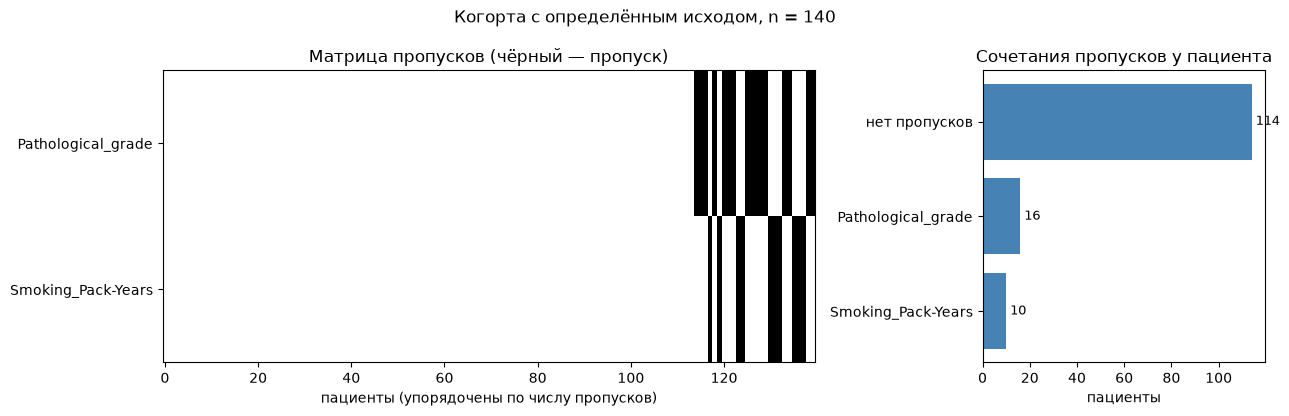

In [12]:
miss_c = pd.DataFrame({"n_missing": cohort.isna().sum(), "share_%": (cohort.isna().mean() * 100).round(1)})
miss_c = miss_c[miss_c.n_missing > 0].sort_values("n_missing", ascending=False)
print(f"Пропуски в когорте с определённым исходом (n = {len(cohort)}):")
print(miss_c.to_string())
print()
over = miss_c[miss_c["share_%"] > MISSING_SHARE_MAX * 100]
print(f"Переменных с долей пропусков > {MISSING_SHARE_MAX:.0%}: {len(over)}")
plot_missing(cohort[clinical_cols + ["Dose_per_fraction"]].drop(columns=[TARGET_SRC]),
             f"Когорта с определённым исходом, n = {len(cohort)}")

## 4. Признаки
### 4.1. Идентификатор, источники целевой переменной, недоступные в момент применения модели

In [13]:
excluded = {
    ID: "идентификатор (сохраняется как ключ строки, не признак)",
    TARGET_SRC: "источник целевой переменной",
    "Fold": "служебная: часть набора соревнования",
    "Radiation_treatment_course_duration": "фактическая длительность ЛТ известна только после её окончания",
    "KM_Overall_survival_censor": "жизненный статус на момент последнего наблюдения — после момента применения",
}
features = [c for c in df.columns if c not in excluded and c != "Target_local_recurrence"]
print(pd.Series(excluded).to_string())
print(f"\nКандидатов в признаки: {len(features)}")

Patient_ID                                                 идентификатор (сохраняется как ключ строки, не признак)
Local_tumor_recurrence                                                                 источник целевой переменной
Fold                                                                          служебная: часть набора соревнования
Radiation_treatment_course_duration                 фактическая длительность ЛТ известна только после её окончания
KM_Overall_survival_censor             жизненный статус на момент последнего наблюдения — после момента применения

Кандидатов в признаки: 123


### 4.2. Константы и дубликаты (в когорте с определённым исходом)

In [14]:
nun = cohort[features].nunique(dropna=True)
constants = nun[nun <= 1].index.tolist()
print("Константы:", constants, "| Fold в когорте:", cohort.Fold.unique().tolist())

top_share = cohort[features].apply(lambda s: s.value_counts(normalize=True, dropna=True).iloc[0])
print("Признаки, где одно значение у > 95 % пациентов:", top_share[top_share > 0.95].round(3).to_dict())

dup_mask = cohort[features].T.duplicated(keep="first")
duplicates = {}
for c in dup_mask[dup_mask].index:
    twin = next(f for f in features if f != c and cohort[f].equals(cohort[c]))
    duplicates[c] = twin
print("Дубликаты (столбец -> совпадающий с ним):", duplicates)
print("Совпадают и во всей таблице:", {c: bool(df[c].equals(df[t])) for c, t in duplicates.items()})
features = [f for f in features if f not in constants and f not in duplicates]
print(f"Признаков после удаления констант и дубликатов: {len(features)}")

Константы: [] | Fold в когорте: ['Training']


Признаки, где одно значение у > 95 % пациентов: {}
Дубликаты (столбец -> совпадающий с ним): {'GTVp_firstorder_TotalEnergy': 'GTVp_firstorder_Energy'}
Совпадают и во всей таблице: {'GTVp_firstorder_TotalEnergy': True}
Признаков после удаления констант и дубликатов: 122


### 4.3. Сокращение избыточных количественных признаков

In [15]:
quant_clin = ["Age_at_diagnosis", "Smoking_Pack-Years", "Total_prescribed_Radiation_treatment_dose",
              "Dose_per_fraction", "#_Radiation_treatment_fractions"]
cls_order = ["shape", "firstorder", "glcm", "glrlm", "glszm", "gldm", "ngtdm"]
first = ["GTVp_shape_MeshVolume", "GTVp_shape_Sphericity"]
rad = [f for f in features if f.startswith("GTVp_")]
rad_order = first + sorted([f for f in rad if f not in first],
                           key=lambda f: (cls_order.index(f.split("_")[1]), rad.index(f)))
order = [f for f in quant_clin if f in features] + rad_order   # порядок приоритета, без использования исхода
print(f"Количественных признаков на входе: {len(order)}")
print("Первые 8 в порядке приоритета:", order[:8])

rho = cohort[order].corr(method="spearman").abs()      # попарно полные наблюдения, n = 140
kept, replaced_by = [], {}
for f in order:
    hit = [k for k in kept if rho.loc[f, k] > CORR_THRESHOLD]
    if hit:
        replaced_by[f] = max(hit, key=lambda k: rho.loc[f, k])   # закрепляем за самым сильно связанным оставленным
    else:
        kept.append(f)
print(f"Оставлено: {len(kept)}; исключено как избыточные: {len(replaced_by)} (порог |rho| > {CORR_THRESHOLD})")

Количественных признаков на входе: 111
Первые 8 в порядке приоритета: ['Age_at_diagnosis', 'Smoking_Pack-Years', 'Total_prescribed_Radiation_treatment_dose', 'Dose_per_fraction', '#_Radiation_treatment_fractions', 'GTVp_shape_MeshVolume', 'GTVp_shape_Sphericity', 'GTVp_shape_Elongation']


Оставлено: 43; исключено как избыточные: 68 (порог |rho| > 0.9)


In [16]:
# сколько исключённых признаков заменяет каждый оставленный (включая дубликаты, закреплённые транзитивно)
def root(f):
    f = duplicates.get(f, f)
    while f in replaced_by:
        f = replaced_by[f]
    return f

absorbed = pd.Series([root(f) for f in list(replaced_by) + list(duplicates)]).value_counts()
summary = pd.DataFrame({"признак": kept, "заменяет исключённых": [int(absorbed.get(k, 0)) for k in kept]})
print(summary.to_string(index=False))
print(f"\nСумма: {summary['заменяет исключённых'].sum()} = {len(replaced_by)} избыточных + {len(duplicates)} дубликат")
print()
for k in kept:
    names = [f.removeprefix("GTVp_") for f in list(replaced_by) + list(duplicates) if root(f) == k]
    if names:
        print(f"{k.removeprefix('GTVp_')}: {', '.join(names)}")

                                      признак  заменяет исключённых
                             Age_at_diagnosis                     0
                           Smoking_Pack-Years                     0
    Total_prescribed_Radiation_treatment_dose                     0
                            Dose_per_fraction                     1
                        GTVp_shape_MeshVolume                    13
                        GTVp_shape_Sphericity                     0
                        GTVp_shape_Elongation                     0
                          GTVp_shape_Flatness                     0
                   GTVp_shape_MajorAxisLength                     3
            GTVp_shape_Maximum2DDiameterSlice                     0
                GTVp_shape_SurfaceVolumeRatio                     0
                 GTVp_firstorder_10Percentile                     0
                 GTVp_firstorder_90Percentile                     0
                      GTVp_firstorder_Entropy   

Максимальная |rho| среди оставленных: 0.8999 (GTVp_firstorder_Minimum — GTVp_glrlm_LongRunLowGrayLevelEmphasis)
Пар с |rho| > 0.9: 0


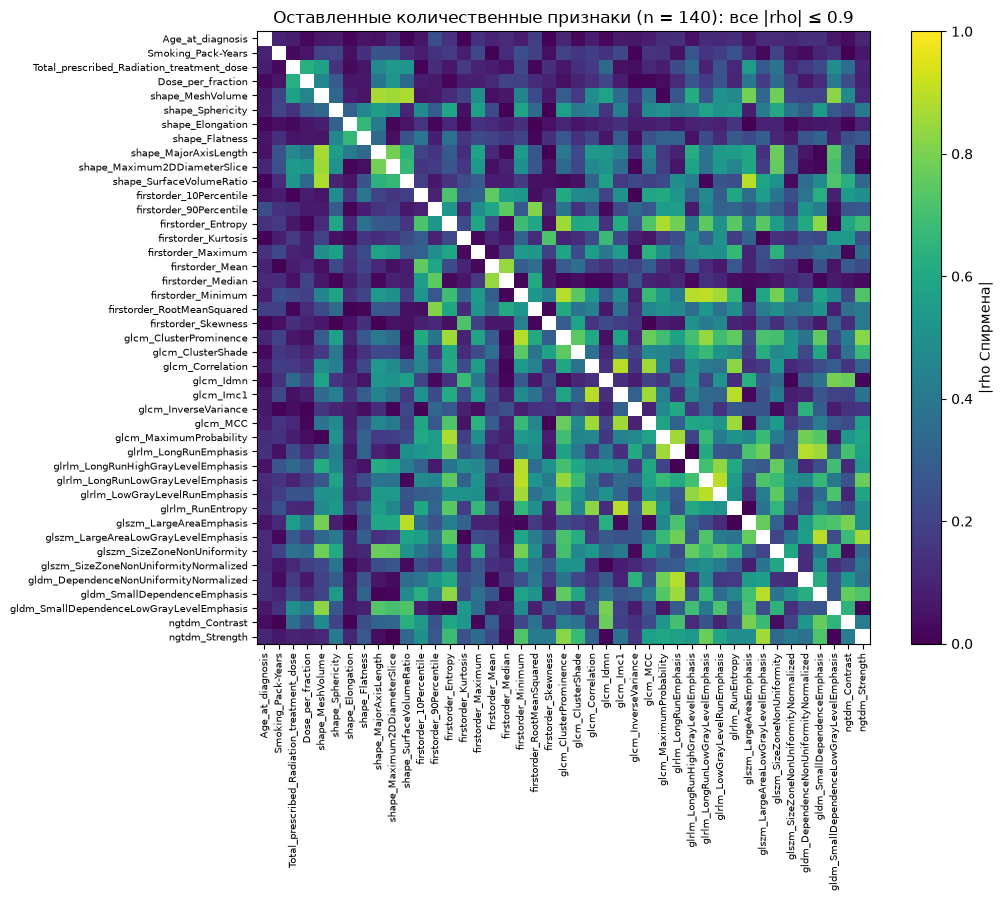

In [17]:
r_kept = cohort[kept].corr(method="spearman").abs().copy()
r_kept = r_kept.mask(np.eye(len(kept), dtype=bool))
i, j = np.unravel_index(np.nanargmax(r_kept.values), r_kept.shape)
print(f"Максимальная |rho| среди оставленных: {r_kept.values[i, j]:.4f} ({kept[i]} — {kept[j]})")
print(f"Пар с |rho| > {CORR_THRESHOLD}: {int((r_kept.values > CORR_THRESHOLD).sum() // 2)}")
assert np.nanmax(r_kept.values) <= CORR_THRESHOLD

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(r_kept, vmin=0, vmax=1, cmap="viridis")
short = [k.removeprefix("GTVp_") for k in kept]
ax.set_xticks(range(len(kept)), short, rotation=90, fontsize=7)
ax.set_yticks(range(len(kept)), short, fontsize=7)
fig.colorbar(im, ax=ax, label="|rho Спирмена|")
ax.set_title(f"Оставленные количественные признаки (n = {len(cohort)}): все |rho| ≤ {CORR_THRESHOLD}")
fig.tight_layout()
plt.show()

## 5. Аналитическая таблица

In [18]:
cat_features = [f for f in features if f not in order]
final_features = cat_features + kept
analytic = cohort[[ID, "Target_local_recurrence"] + final_features].sort_values(ID).reset_index(drop=True)
assert analytic[ID].is_unique and analytic.Target_local_recurrence.notna().all()
analytic.to_csv(OUT_CSV, index=False)

check = pd.read_csv(OUT_CSV)
print(f"Файл: {OUT_CSV}")
print(f"Пациентов (строк): {len(check)}; уникальных {ID}: {check[ID].nunique()}")
print(f"Признаков: {check.shape[1] - 2} = {len(cat_features)} категориальных + "
      f"{len([k for k in kept if not k.startswith('GTVp_')])} количественных клинических + "
      f"{len([k for k in kept if k.startswith('GTVp_')])} радиомических")
print(f"Столбцов: {check.shape[1]} (код пациента, целевая переменная, признаки)")
print(f"Исход 1: {int(check.Target_local_recurrence.sum())}, исход 0: {int((check.Target_local_recurrence == 0).sum())}")
print(f"Пропусков в таблице: {int(check.isna().sum().sum())} (не заполнялись)")
check.head()

Файл: analytic_table.csv
Пациентов (строк): 140; уникальных Patient_ID: 140
Признаков: 54 = 11 категориальных + 4 количественных клинических + 39 радиомических
Столбцов: 56 (код пациента, целевая переменная, признаки)
Исход 1: 12, исход 0: 128
Пропусков в таблице: 26 (не заполнялись)


,Patient_ID,Target_local_recurrence,Gender,Race,Tumor_side,Tumor_subsite,T_category,N_category,AJCC_Stage,Pathological_grade,Smoking_status_at_diagnosis,Induction_Chemotherapy,Concurrent_chemotherapy,Age_at_diagnosis,Smoking_Pack-Years,Total_prescribed_Radiation_treatment_dose,Dose_per_fraction,GTVp_shape_MeshVolume,GTVp_shape_Sphericity,GTVp_shape_Elongation,...,GTVp_glcm_Correlation,GTVp_glcm_Idmn,GTVp_glcm_Imc1,GTVp_glcm_InverseVariance,GTVp_glcm_MCC,GTVp_glcm_MaximumProbability,GTVp_glrlm_LongRunEmphasis,GTVp_glrlm_LongRunHighGrayLevelEmphasis,GTVp_glrlm_LongRunLowGrayLevelEmphasis,GTVp_glrlm_LowGrayLevelRunEmphasis,GTVp_glrlm_RunEntropy,GTVp_glszm_LargeAreaEmphasis,GTVp_glszm_LargeAreaLowGrayLevelEmphasis,GTVp_glszm_SizeZoneNonUniformity,GTVp_glszm_SizeZoneNonUniformityNormalized,GTVp_gldm_DependenceNonUniformityNormalized,GTVp_gldm_SmallDependenceEmphasis,GTVp_gldm_SmallDependenceLowGrayLevelEmphasis,GTVp_ngtdm_Contrast,GTVp_ngtdm_Strength
0,1,0,Male,White,L,Tonsil,2,0,II,III,Former,N,N,58,5.0,66,2.200,7579.750000,0.575287,0.979116,...,0.724440,0.997178,-0.229026,0.439498,0.784492,0.118314,2.675293,2119.192880,0.003752,0.001644,4.620838,10256.443447,12.611718,187.175943,0.336043,0.062476,0.082131,0.000322,0.013731,1.498985
1,2,0,Female,White,R,BOT,3,0,III,II,Former,N,Y,78,70.0,70,2.000,22845.625000,0.508522,0.790523,...,0.631086,0.997737,-0.165317,0.441573,0.700637,0.142328,3.492656,6533.052043,0.002619,0.001182,4.492682,50555.089418,26.685593,911.140741,0.482085,0.049280,0.086157,0.000222,0.009731,2.525736
2,4,0,Female,White,R,BOT,2,2b,IV,III,Never,N,Y,56,0.0,66,2.200,9993.666667,0.568192,0.642971,...,0.408696,0.998387,-0.098435,0.471116,0.528129,0.269305,3.943166,3729.202294,0.004366,0.001268,3.767109,65960.670259,69.299271,213.857759,0.460900,0.050755,0.053903,0.000178,0.004286,1.488254
3,5,0,Female,White,L,Tonsil,2,2b,IV,II,Never,N,Y,60,0.0,70,2.121,4568.750000,0.546794,0.826105,...,0.700573,0.997713,-0.218480,0.445184,0.831608,0.081253,2.589455,2043.158611,0.003792,0.001769,4.412996,4846.877358,5.902439,103.553459,0.325640,0.067303,0.078694,0.000422,0.013632,2.474913
4,6,0,Male,White,R,BOT,1,1,III,III,Never,N,Y,66,0.0,66,2.200,784.583333,0.719560,0.887237,...,0.175741,0.994202,-0.047397,0.422969,0.304517,0.309239,4.558386,323.904169,0.067496,0.016784,3.166733,7857.028571,111.976781,15.742857,0.449796,0.048400,0.047787,0.002110,0.010574,0.475730


## 6. Сводка для словаря переменных

In [19]:
rows = clinical_cols + ["Dose_per_fraction", "Target_local_recurrence"] + [k for k in kept if k.startswith("GTVp_")]
status = {}
for c in rows:
    if c in excluded:
        status[c] = "исключена"
    elif c == "Target_local_recurrence":
        status[c] = "целевая"
    elif c in final_features:
        status[c] = "признак"
    else:
        status[c] = "исключена (избыточность)"
dict_summary = pd.DataFrame({
    "пропуски_298": [int(df[c].isna().sum()) for c in rows],
    "пропуски_140": [int(cohort[c].isna().sum()) for c in rows],
    "решение": [status[c] for c in rows],
    "заменяет": [int(absorbed.get(c, 0)) if c in kept else "" for c in rows],
}, index=rows)
with pd.option_context("display.max_rows", 200):
    display(dict_summary)
print(f"Радиомических признаков: исходно {len(radiomic_cols)}, оставлено {len([k for k in kept if k.startswith('GTVp_')])}")

,пропуски_298,пропуски_140,решение,заменяет
Patient_ID,0,0,исключена,
Fold,0,0,исключена,
Local_tumor_recurrence,158,0,исключена,
Gender,0,0,признак,
Age_at_diagnosis,0,0,признак,0
Race,1,0,признак,
Tumor_side,0,0,признак,
Tumor_subsite,0,0,признак,
T_category,0,0,признак,
N_category,1,0,признак,


Радиомических признаков: исходно 107, оставлено 39
